# Proiettare le Coordinate dei Centri per lo Studio Clinico per la Mappatura con PROC GPROJECT

## Sintesi Esecutiva

Un team di operazioni cliniche deve tracciare l'impronta geografica di uno studio di Fase III multicentrico su una mappa piana. Questo notebook genera coordinate sintetiche di latitudine/longitudine per i centri dello studio, raggruppati attorno a cinque hub regionali statunitensi, e poi usa **PROC GPROJECT** per convertire le coordinate sferiche in valori cartesiani X/Y usando tre metodi di proiezione (equivalente di Albers, conforme di Lambert con paralleli standard personalizzati e ritaglio regionale, e Gnomonica centrata sugli USA continentali), illustrando come la scelta della proiezione e il ritaglio influenzino una mappa dei centri.

## Fonti dei Dati

| Dataset | Righe | Variabili Chiave | Descrizione |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 hub x 12 centri) | `site_id` (ID $8), `region` ($9), `x` (longitudine, gradi, positiva a est), `y` (latitudine, gradi), `enroll` (soggetti arruolati), `segment` (id del segmento di mappa) | Posizioni sintetiche di centri di uno studio clinico di Fase III, distribuite attorno a cinque hub regionali statunitensi (Ovest, Midwest, Nordest, Sud, Sudest) usando jitter con `rand('normal')` e conteggi di arruolamento con `rand('poisson')` |

# Proiettare le Coordinate dei Centri per lo Studio Clinico con PROC GPROJECT

Quando uno sponsor conduce uno studio di Fase III geograficamente disperso, il gruppo di operazioni cliniche vuole spesso un'unica mappa che mostri ogni centro sperimentale, dimensionato o colorato in base all'arruolamento. Le posizioni dei centri arrivano come **coppie longitudine/latitudine**, ma una mappa piana richiede **coordinate planari X/Y**. `PROC GPROJECT` esegue questa conversione da sferiche a cartesiane, applicando una proiezione cartografica così che distanze e aree siano rese in modo sensato.

In questo notebook:

1. Generiamo coordinate sintetiche dei centri raggruppate attorno a cinque hub regionali statunitensi.
2. Applichiamo la proiezione predefinita **equivalente di Albers**.
3. Applichiamo una proiezione **conforme di Lambert** con paralleli standard personalizzati e ritaglio agli USA contigui.
4. Applichiamo una proiezione **Gnomonica** centrata sul punto medio geografico del paese, mantenendo le coordinate originali con `ASIS`.

Tutto è autonomo: nessun file esterno, nessuna rete.

## Passo 1 — Generare coordinate sintetiche dei centri dello studio

Inizializziamo il generatore di numeri casuali con `call streaminit` per la riproducibilità, quindi collochiamo 12 centri attorno a ciascuna delle cinque città hub regionali. Le longitudini sono memorizzate positive a est in gradi (negative per l'emisfero occidentale) e le latitudini in gradi. Ogni riga porta anche un conteggio di arruolamento e una variabile `segment` (GPROJECT preserva le colonne non di coordinate durante la proiezione).

In [1]:
DATI trial_sites;
    CHIAMARE streaminit(20260531);
    LUNGHEZZA site_id $8 region $9;
    /* Cinque hub regionali degli USA: longitudine (est+), latitudine */
    VETTORE clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    VETTORE clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);
    VETTORE rname[5] $9 _temporary_ ('Ovest' 'Midwest' 'Nordest' 'Sud' 'Sudest');

    FARE hub = 1 FINO_A 5;
        region = rname[hub];
        FARE s = 1 FINO_A 12;
            site_id = cats('S', PUT(hub, z1.), PUT(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* longitudine, gradi */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* latitudine,  gradi */
            enroll  = round(rand('poisson', 60));           /* soggetti arruolati */
            segment = 1;
            USCITA;
        FINE;
    FINE;
    RIMUOVERE hub s;
ESEGUIRE;

PROCEDURA STAMPARE DATI=trial_sites(obs=10) ETICHETTA;
    ETICHETTA site_id="ID Centro" region="Regione" x="Longitudine" y="Latitudine"
          enroll="Arruolati" segment="Segmento";
    TITOLO "Campione di Centri Sintetici dello Studio Clinico (lon/lat non proiettati)";
ESEGUIRE;

                       Campione di Centri Sintetici dello Studio Clinico (lon/lat non proiettati)                       

  Obs  ID Centro  Regione      Longitudine     Latitudine  Arruolati  Segmento
    1  S101       Ovest    -121.6437232216  37.7677668495         65         1
    2  S102       Ovest    -120.7384024716  37.5083287903         61         1
    3  S103       Ovest    -121.5133780284  37.8633933883         72         1
    4  S104       Ovest    -121.2086817368  38.7723343392         68         1
    5  S105       Ovest    -121.0499572297   37.175813806         54         1
    6  S106       Ovest    -124.0531899967   35.778231667         72         1
    7  S107       Ovest    -120.9370181032  39.0576714397         64         1
    8  S108       Ovest    -126.8495029747  36.6474680375         55         1
    9  S109       Ovest     -123.475989897  37.1427965254         56         1
   10  S110       Ovest     -122.579780071   36.931533678         57         1

... 50 m


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Passo 2 — Proiezione predefinita equivalente di Albers

La proiezione conica equivalente di **Albers** è quella predefinita di GPROJECT ed è una scelta sensata per una mappa a scala nazionale dove conta preservare l'*area relativa* (ad es. confrontare la dimensione di bacini di utenza regionali).

Poiché le nostre coordinate sono memorizzate in **gradi** con **longitudine positiva a est**, specifichiamo le opzioni `DEGREE` e `EASTLONG`. L'istruzione `ID` indica la variabile che identifica in modo univoco ciascuna unità; le coordinate planari proiettate vengono riscritte in `x` e `y` nel dataset `OUT=`.

In [2]:
PROCEDURA GPROJECT DATI=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
ESEGUIRE;

PROCEDURA STAMPARE DATI=sites_albers(obs=10) ETICHETTA;
    ETICHETTA site_id="ID Centro" region="Regione" x="Longitudine (proiettata)" y="Latitudine (proiettata)"
          enroll="Arruolati" segment="Segmento";
    TITOLO "Centri dopo la Proiezione Equivalente di Albers (X/Y planari)";
ESEGUIRE;

                       Campione di Centri Sintetici dello Studio Clinico (lon/lat non proiettati)                       

                             Centri dopo la Proiezione Equivalente di Albers (X/Y planari)                              

  Obs  ID Centro  Regione  Longitudine (proiettata)  Latitudine (proiettata)  Arruolati  Segmento
    1  S101       Ovest                -0.346124731             0.0516986079         65         1
    2  S102       Ovest               -0.3353644139             0.0440400181         61         1
    3  S103       Ovest               -0.3439609675             0.0528501365         72         1
    4  S104       Ovest               -0.3357513354              0.067213083         68         1
    5  S105       Ovest               -0.3410170723             0.0394882801         54         1
    6  S106       Ovest               -0.3879364507             0.0273340733         72         1
    7  S107       Ovest               -0.3309127579             0.0711


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Passo 3 — Proiezione conforme di Lambert con paralleli personalizzati e ritaglio

La proiezione conica **conforme di Lambert** preserva *forma e angoli locali*, il che è preferibile quando la mappa è usata per la navigazione o per sovrapporre elementi direzionali. Per gli USA contigui, i paralleli standard vicino a 33 gradi N e 45 gradi N sono convenzionali, quindi li impostiamo esplicitamente con `PARALLEL1=` e `PARALLEL2=`.

Limitiamo anche la mappa alla finestra degli USA contigui usando le opzioni di ritaglio `LATMIN=`, `LATMAX=`, `LONGMIN=` e `LONGMAX=`. Qualsiasi centro che ricada fuori da questo riquadro di latitudine/longitudine viene eliminato prima della proiezione, quindi il numero di osservazioni in output può essere inferiore a quello in input.

In [3]:
PROCEDURA GPROJECT DATI=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
ESEGUIRE;

PROCEDURA STAMPARE DATI=sites_lambert(obs=10) ETICHETTA;
    ETICHETTA site_id="ID Centro" region="Regione" x="Longitudine (proiettata)" y="Latitudine (proiettata)"
          enroll="Arruolati" segment="Segmento";
    TITOLO "Centri dopo la Proiezione Conforme di Lambert (ritagliata agli USA contigui)";
ESEGUIRE;

                             Centri dopo la Proiezione Equivalente di Albers (X/Y planari)                              

                      Centri dopo la Proiezione Conforme di Lambert (ritagliata agli USA contigui)                      

  Obs  ID Centro  Regione  Longitudine (proiettata)  Latitudine (proiettata)  Arruolati  Segmento
    1  S101       Ovest               -0.3473024124             0.0279382533         65         1
    2  S102       Ovest               -0.3365626234             0.0201991247         61         1
    3  S103       Ovest               -0.3451238364             0.0290365995         72         1
    4  S104       Ovest               -0.3367881094             0.0430616123         68         1
    5  S105       Ovest               -0.3422656751             0.0158037156         54         1
    6  S106       Ovest               -0.3894389642             0.0046370991         72         1
    7  S107       Ovest               -0.3319086764             0.0468


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Passo 4 — Proiezione Gnomonica centrata sul paese, mantenendo gli originali

La proiezione azimutale **Gnomonica** rende ogni cerchio massimo come una linea retta, il che è utile quando si vuole ragionare sul percorso più breve tra i centri (ad esempio, pianificare l'itinerario di visita di un monitor). La distorsione cresce con la distanza dal polo di proiezione, quindi centriamo il polo sul punto medio geografico degli USA continentali con `POLELAT=39` e `POLELONG=-98`.

L'opzione `ASIS` indica a GPROJECT di conservare le coordinate originali non proiettate insieme ai valori proiettati, così il dataset in output porta sia le coordinate planari `X`/`Y` sia le coordinate sorgente `LONG`/`LAT` — utile per ricongiungere le metriche di arruolamento a entrambi gli spazi di coordinate.

L'istruzione `PARMENTRY` è mostrata come un modo alternativo per fornire i parametri di proiezione come override chiave=valore.

In [4]:
PROCEDURA GPROJECT DATI=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
ESEGUIRE;

PROCEDURA STAMPARE DATI=sites_gnomon(obs=10) ETICHETTA;
    ETICHETTA site_id="ID Centro" region="Regione" x="X (proiettata)" y="Y (proiettata)"
          enroll="Arruolati" segment="Segmento" long="Longitudine originale" lat="Latitudine originale";
    TITOLO "Centri dopo la Proiezione Gnomonica (ASIS mantiene LONG/LAT originali)";
ESEGUIRE;

                      Centri dopo la Proiezione Conforme di Lambert (ritagliata agli USA contigui)                      

                         Centri dopo la Proiezione Gnomonica (ASIS mantiene LONG/LAT originali)                         

  Obs  ID Centro  Regione  X (proiettata)  Y (proiettata)  Arruolati  Segmento  Longitudine originale  Latitudine originale
    1  S101       Ovest     -0.3343477981    0.0213614461         65         1        -121.6437232216         37.7677668495
    2  S102       Ovest     -0.3221611694    0.0134152735         61         1        -120.7384024716         37.5083287903
    3  S103       Ovest     -0.3319480803    0.0225717184         72         1        -121.5133780284         37.8633933883
    4  S104       Ovest     -0.3230855797    0.0375741352         68         1        -121.2086817368         38.7723343392
    5  S105       Ovest     -0.3283677206    0.0086308769         54         1        -121.0499572297          37.175813806
    6  S106 


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Passo 5 — Renderizzare la mappa dei centri proiettati

Il punto centrale della proiezione è disegnare la mappa. Passiamo il dataset `OUT=` di Albers direttamente a **PROC SGPLOT**, tracciando le coordinate planari `X`/`Y` e colorando ogni marcatore in base a `region`. Poiché la proiezione ha preservato la geografia relativa, i cinque cluster degli hub si collocano negli angoli attesi del grafico — Ovest a sinistra, Nordest in alto a destra, Sud e Sudest lungo il fondo — offrendo alle operazioni cliniche l'impronta fedele all'area descritta nella sintesi esecutiva.

                         Centri dopo la Proiezione Gnomonica (ASIS mantiene LONG/LAT originali)                         




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


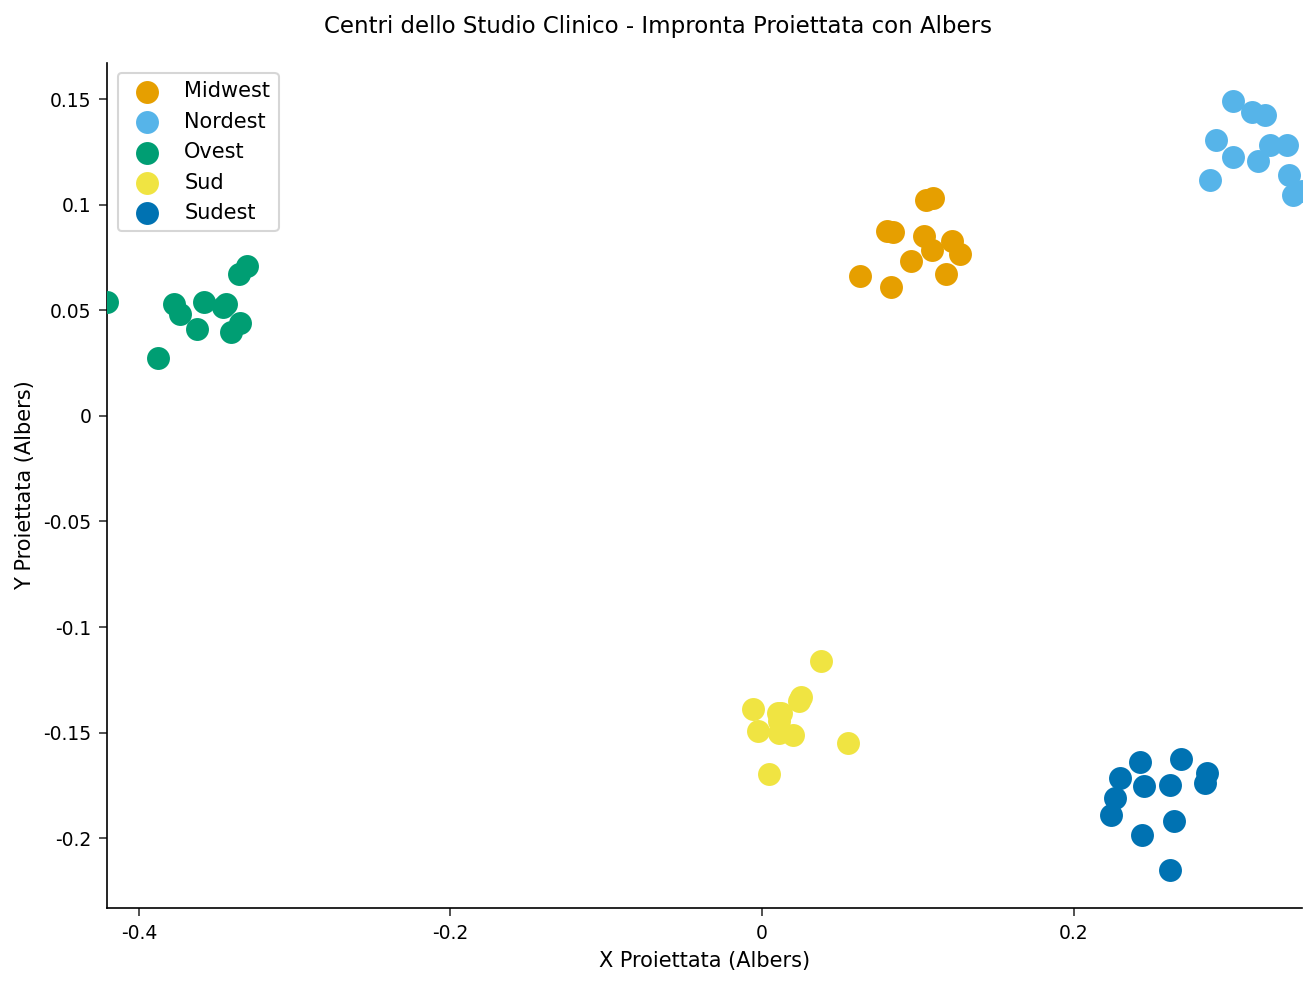

In [5]:
PROCEDURA SGPLOT DATI=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS ETICHETTA="X Proiettata (Albers)";
    YAXIS ETICHETTA="Y Proiettata (Albers)";
    TITOLO "Centri dello Studio Clinico - Impronta Proiettata con Albers";
ESEGUIRE;

## Interpretare i risultati

- **Albers (Passo 2)** ha trasformato tutti e 60 i centri in coordinate planari preservando l'area relativa — i cluster Ovest, Midwest, Nordest, Sud e Sudest mantengono la loro impronta spaziale proporzionale, la base corretta per una mappa di calore dell'arruolamento fedele all'area.
- **Lambert con ritaglio (Passo 3)** ha preservato la forma locale e, applicando la finestra `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, ha eliminato i centri sintetici dispersi fuori dagli USA contigui — qui il conteggio è sceso da 60 a 58, così le due coordinate fuori griglia che altrimenti avrebbero allungato la mappa sono state rimosse prima della proiezione.
- **Gnomonica con `ASIS` (Passo 4)** ha centrato la proiezione sull'interno del paese e, grazie ad `ASIS`, ha prodotto un dataset che porta sia le coordinate proiettate `X`/`Y` sia quelle originali `LONG`/`LAT`. I cerchi massimi appaiono come linee rette, quindi le distanze in linea retta su questa mappa approssimano i percorsi più brevi reali tra i centri.
- **L'impronta renderizzata (Passo 5)** conferma che la proiezione ha funzionato: tracciando le `X`/`Y` di Albers per regione, i cinque cluster degli hub si collocano negli angoli attesi del piano, la mappa dei centri fedele all'area promessa dalla sintesi esecutiva.

**Conclusione per le operazioni cliniche:** la proiezione non è cosmetica. Scegliere **Albers** per una densità di arruolamento fedele all'area, **Lambert** per sovrapposizioni fedeli alla forma con ritaglio regionale, e **Gnomonica** quando la distanza di viaggio tra i centri guida l'analisi. Come mostra il Passo 5, il dataset proiettato `OUT=` si inserisce direttamente in PROC SGPLOT (o PROC GMAP) per renderizzare la mappa finale dei centri.